In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import matplotlib.ticker as ticker
from IPython.display import display

In [2]:
file_path = '/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv'
df = pd.read_csv(file_path, encoding='windows-1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Überprüfen wie viele Beobachtungen es gibt ( Anzahl Zeilen, Anzahl Spalten)

In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

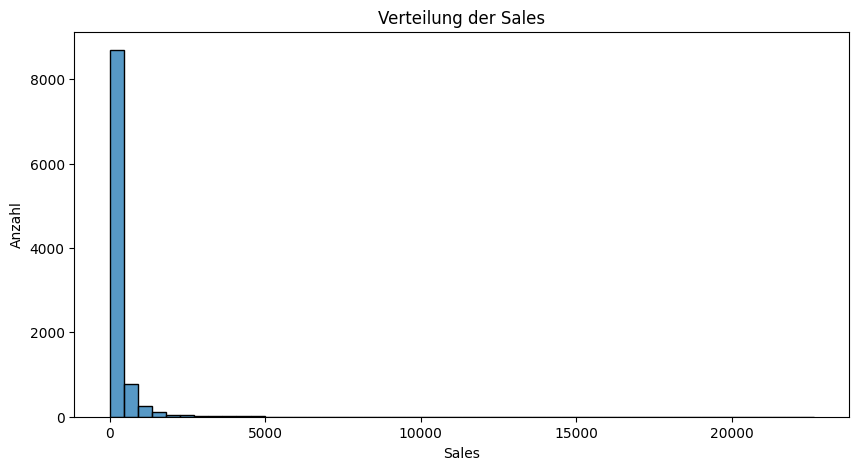

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Sales", bins=50)

plt.title("Verteilung der Sales")
plt.xlabel("Sales")
plt.ylabel("Anzahl")

plt.show()

In [11]:
df["Sales"].quantile([0.90, 0.95, 0.99])

0.90     572.706000
0.95     956.984245
0.99    2481.694600
Name: Sales, dtype: float64

Zoomen auf die ersten 99% für die Visualisierung

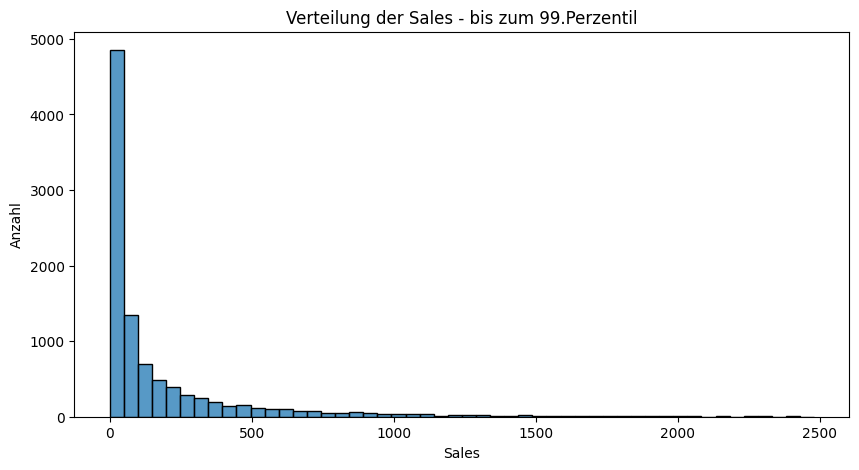

In [12]:
sales_99 = df["Sales"].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(data=df[df["Sales"]<= sales_99], x="Sales", bins = 50)

plt.title("Verteilung der Sales - bis zum 99.Perzentil")
plt.xlabel("Sales")
plt.ylabel("Anzahl")

plt.show()

Sales ist rechtsschief verteilt und enthält einige sehr hohe Werte. 99% der Beobachtungen liegen unter 2251, während das Maximum bei ca. 22638 liegt. Eine spätere Outlier- bzw. Log-Transformation sollte geprüft werden.

In [13]:
df["Profit"].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

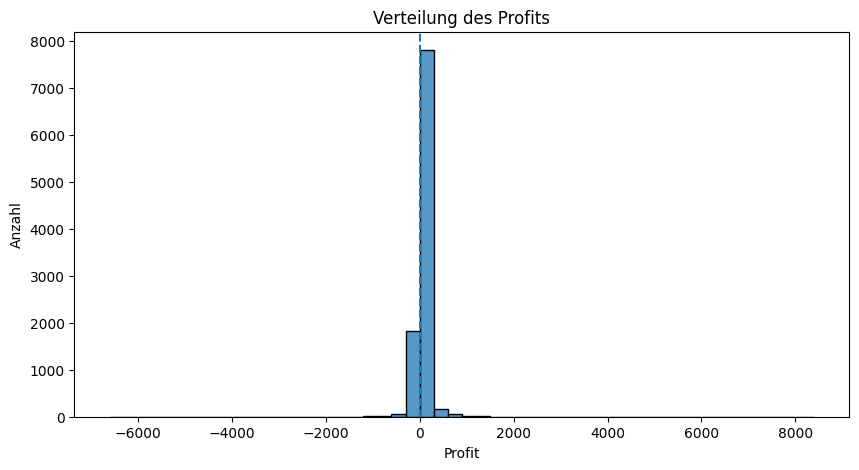

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Profit",
    bins=50
)

plt.axvline(0, linestyle="--")

plt.title("Verteilung des Profits")
plt.xlabel("Profit")
plt.ylabel("Anzahl")

plt.show()

In [15]:
(df["Profit"]<0).sum()

np.int64(1871)

In [16]:
(df["Profit"]<0).mean() * 100

np.float64(18.721232739643785)

In [17]:
df["Profit"].quantile([0.01, 0.05, 0.95, 0.99])

0.01   -319.264953
0.05    -53.030920
0.95    168.470400
0.99    580.657882
Name: Profit, dtype: float64

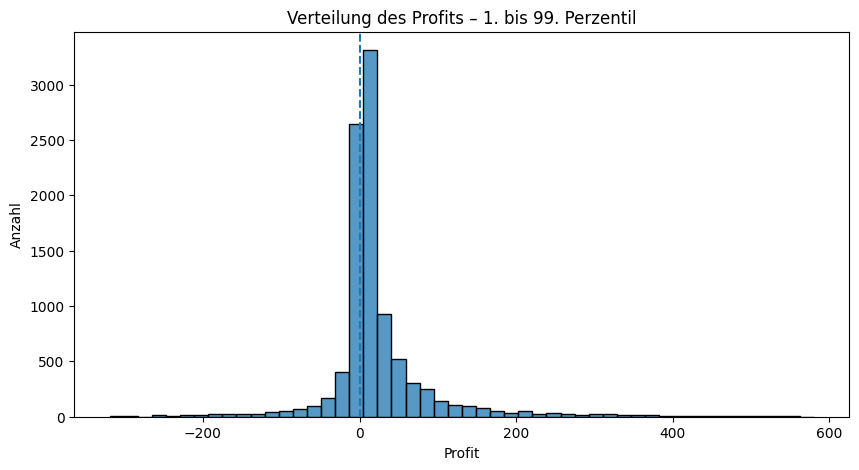

In [18]:
profit_low = df["Profit"].quantile(0.01)
profit_high = df["Profit"].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[
        (df["Profit"] >= profit_low) &
        (df["Profit"] <= profit_high)
    ],
    x="Profit",
    bins=50
)

plt.axvline(0, linestyle="--")

plt.title("Verteilung des Profits – 1. bis 99. Perzentil")
plt.xlabel("Profit")
plt.ylabel("Anzahl")

plt.show()

--> Profit konzentriert sich stark um 0, enthält aber sowohl hohe negative als auch hohe positive Extremwerte. Rund 18,7% der Verkaufspositionen sind verlustbringend.

In [19]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

Was passiert mit dem Profit, wenn der Discount steigt ?

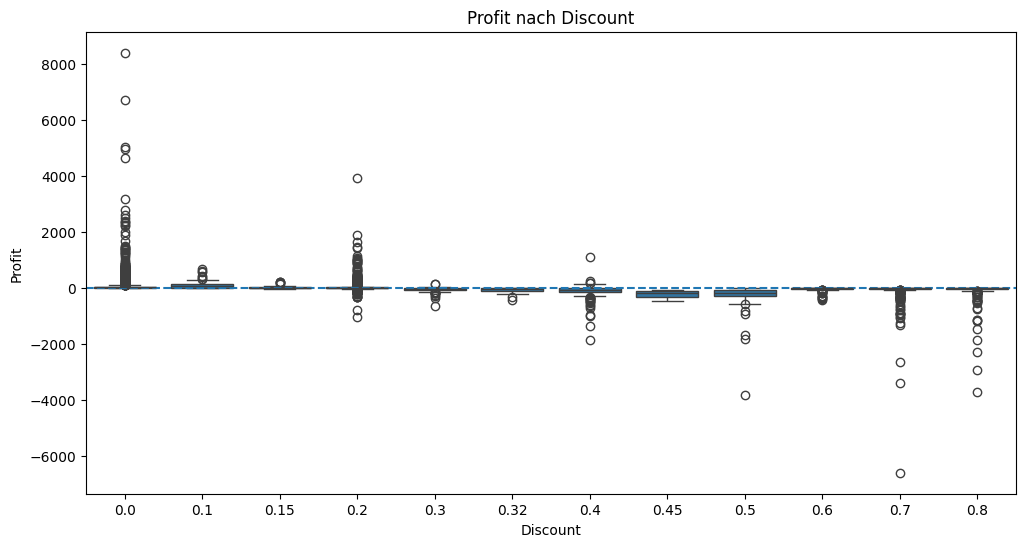

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="Discount", y="Profit")

plt.axhline(0, linestyle="--")

plt.title("Profit nach Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

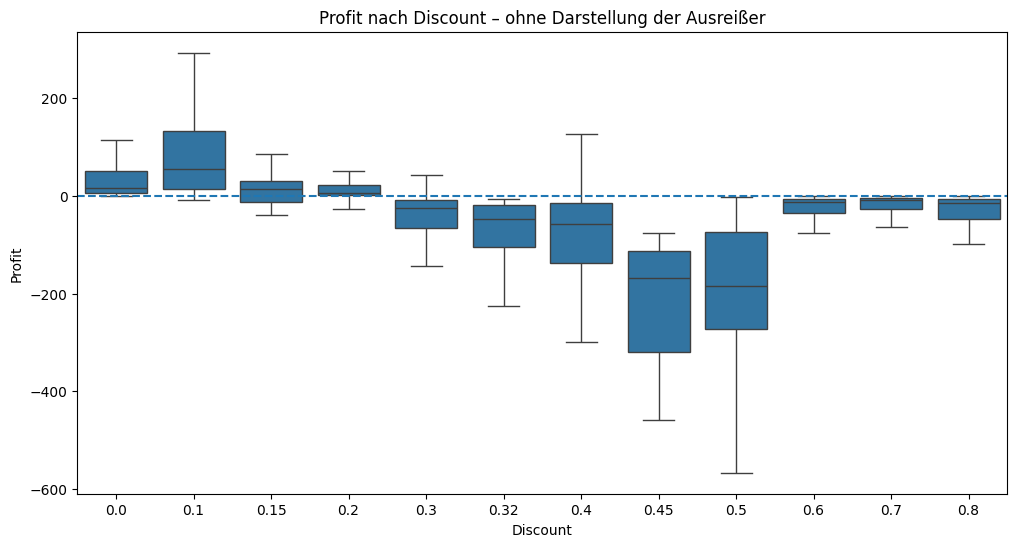

In [21]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Discount",
    y="Profit",
    showfliers=False
)

plt.axhline(0, linestyle="--")

plt.title("Profit nach Discount – ohne Darstellung der Ausreißer")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

--> Discount scheint stark mit Profit zusammenhängen. Ab etwa 30% Rabatt treten typischerweise Verluste auf. Der Zusammenhang ist jedoch nicht streng linear und einige Rabattstufen haben nur wenige Beobachtungen.

In [22]:
df.groupby("Discount")["Profit"].agg(["count", "mean", "median"])

,count,mean,median
Discount,,,
0.00,4798,66.900292,15.9952
0.10,94,96.055074,54.3240
0.15,52,27.288298,14.0980
0.20,3657,24.702572,6.4944
0.30,227,-45.679636,-25.3764
0.32,27,-88.560656,-46.9764
0.40,206,-111.927429,-57.6242
0.45,11,-226.646464,-167.3184
0.50,66,-310.703456,-185.2767


In [23]:
df.groupby("Category")["Profit"].agg(
    ["count", "mean", "median", "sum"]
)

,count,mean,median,sum
Category,,,,
Furniture,2121,8.699327,7.7748,18451.2728
Office Supplies,6026,20.327050,6.8824,122490.8008
Technology,1847,78.752002,25.0182,145454.9481


In [24]:
df.groupby("Category")["Profit"].agg(
    ["count", "mean", "median", "sum"]
)

,count,mean,median,sum
Category,,,,
Furniture,2121,8.699327,7.7748,18451.2728
Office Supplies,6026,20.327050,6.8824,122490.8008
Technology,1847,78.752002,25.0182,145454.9481


In [25]:
subcat_profit = (
    df.groupby("Sub-Category")["Profit"]
      .agg(["count", "mean", "median", "sum"])
      .sort_values("sum", ascending=False)
)

subcat_profit

,count,mean,median,sum
Sub-Category,,,,
Copiers,68,817.909190,332.99420,55617.8249
Phones,889,50.073938,23.52480,44515.7306
Accessories,775,54.111788,21.00000,41936.6357
Paper,1370,24.856620,11.54320,34053.5693
Binders,1523,19.843574,3.97710,30221.7633
Chairs,617,43.095894,13.31760,26590.1663
Storage,846,25.152277,7.75700,21278.8264
Appliances,466,38.922758,17.44650,18138.0054
Furnishings,957,13.645918,9.10200,13059.1436


In [26]:
profit_by_subcategory = (
    df.groupby("Sub-Category", as_index=False)["Profit"]
      .sum()
      .sort_values("Profit", ascending=False)
)

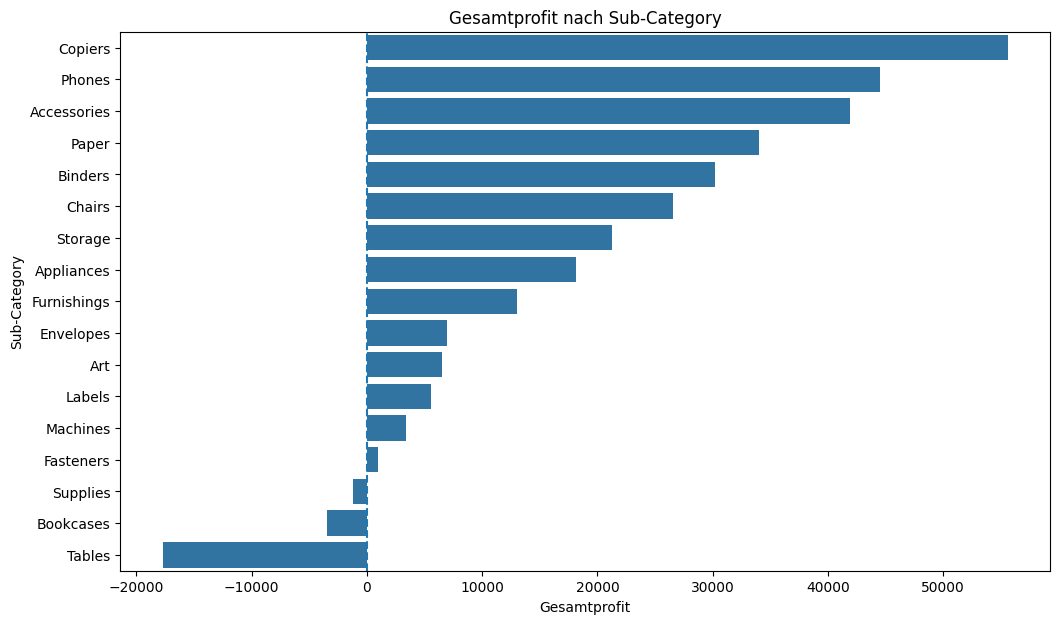

In [27]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=profit_by_subcategory,
    x="Profit",
    y="Sub-Category"
)

plt.axvline(0, linestyle="--")

plt.title("Gesamtprofit nach Sub-Category")
plt.xlabel("Gesamtprofit")
plt.ylabel("Sub-Category")

plt.show()

In [28]:
problem_categories = ["Tables", "Bookcases", "Supplies"]

df[df["Sub-Category"].isin(problem_categories)].groupby(
    "Sub-Category"
)[["Discount", "Profit"]].agg(["count", "mean", "median"])

Discount                  Profit                    
                count      mean median  count       mean   median
Sub-Category                                                     
Bookcases         228  0.211140    0.2    228 -15.230509   4.1333
Supplies          190  0.076842    0.0    190  -6.258418   3.9593
Tables            319  0.261285    0.3    319 -55.565771 -31.3722

In [29]:
df[["Sales", "Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.479064
Profit,0.479064,1.000000


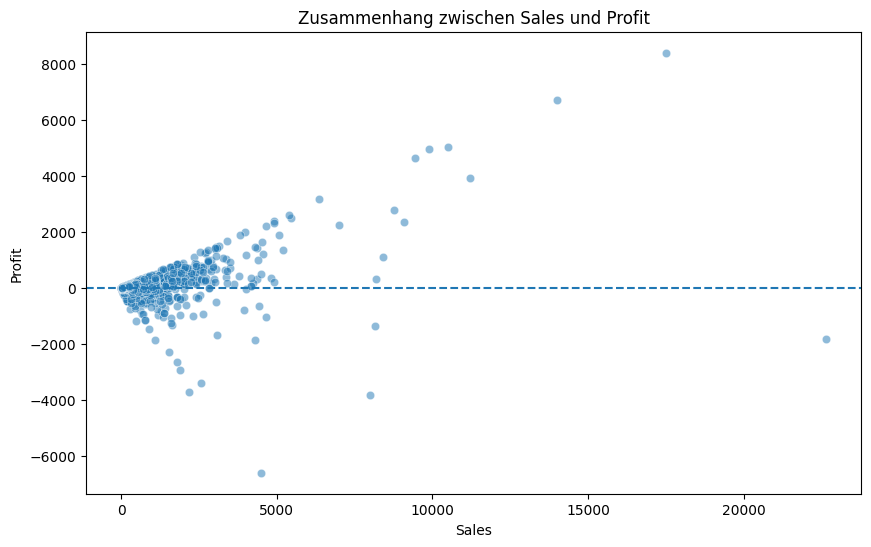

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Zusammenhang zwischen Sales und Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

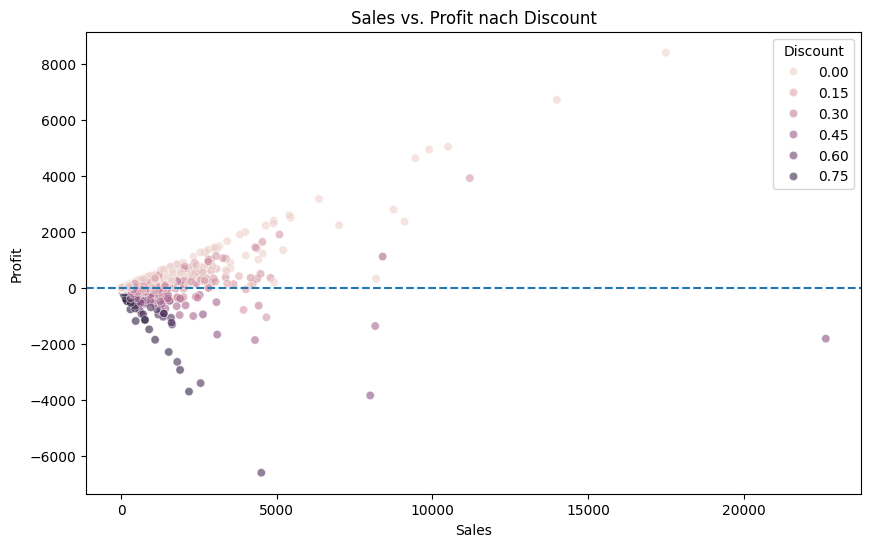

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Discount",
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title("Sales vs. Profit nach Discount")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

In [32]:
df[["Sales", "Quantity", "Discount", "Profit"]].corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


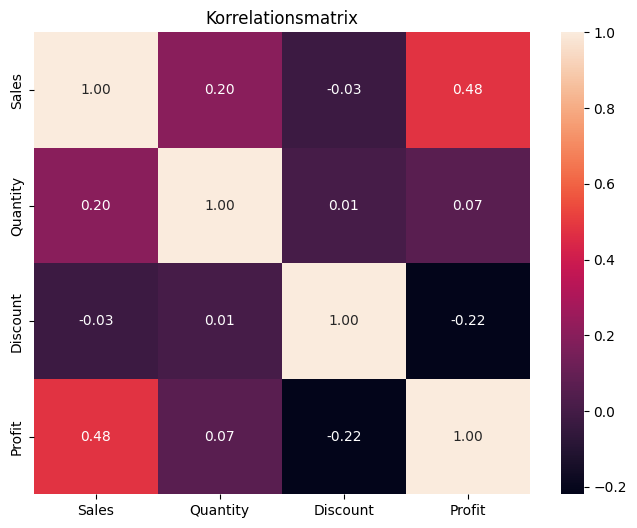

In [33]:
corr_matrix = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Korrelationsmatrix")

plt.show()

In [34]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [35]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [36]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [37]:
df[["Order Date", "Ship Date", "Shipping Days"]].head(10)

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7
5,2014-06-09,2014-06-14,5
6,2014-06-09,2014-06-14,5
7,2014-06-09,2014-06-14,5
8,2014-06-09,2014-06-14,5
9,2014-06-09,2014-06-14,5


In [38]:
df["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [39]:
df["Shipping Days"].value_counts().sort_index()


Shipping Days
0     519
1     369
2    1334
3    1005
4    2774
5    2169
6    1203
7     621
Name: count, dtype: int64

In [40]:
df[["Shipping Days", "Profit", "Sales"]].corr()

,Shipping Days,Profit,Sales
Shipping Days,1.000000,-0.004649,-0.007354
Profit,-0.004649,1.000000,0.479064
Sales,-0.007354,0.479064,1.000000


In [41]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month

In [42]:
df[["Order Date", "Order Year", "Order Month"]].head()

,Order Date,Order Year,Order Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [43]:
yearly = df.groupby("Order Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
)

yearly

,Sales,Profit,Orders
Order Year,,,
2014,484247.4981,49543.9741,969
2015,470532.5090,61618.6037,1038
2016,609205.5980,81795.1743,1315
2017,733215.2552,93439.2696,1687


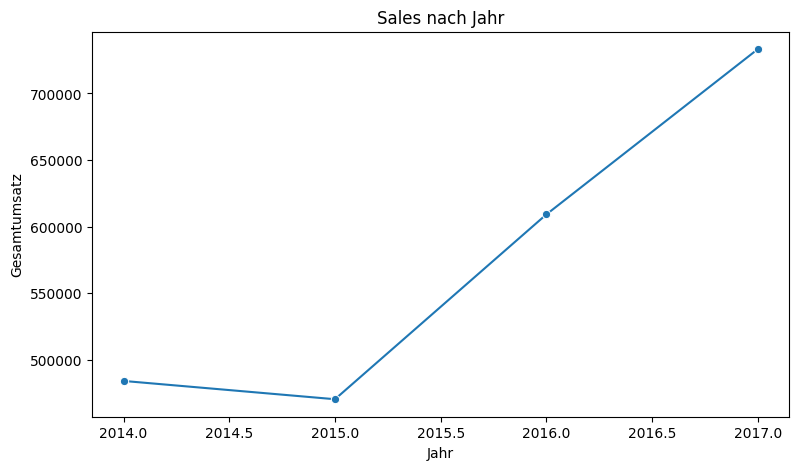

In [44]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly,
    x=yearly.index,
    y="Sales",
    marker="o"
)

plt.title("Sales nach Jahr")
plt.xlabel("Jahr")
plt.ylabel("Gesamtumsatz")

plt.show()

In [45]:
df["Year-Month"] = df["Order Date"].dt.to_period("M")

In [46]:
df[["Order Date", "Year-Month"]].head()

,Order Date,Year-Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [47]:
monthly = (
    df.groupby("Year-Month")["Sales"]
      .sum()
      .reset_index()
)

monthly.head()

,Year-Month,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


In [48]:
monthly.shape

(48, 2)

In [49]:
monthly["Year-Month"] = monthly["Year-Month"].dt.to_timestamp()

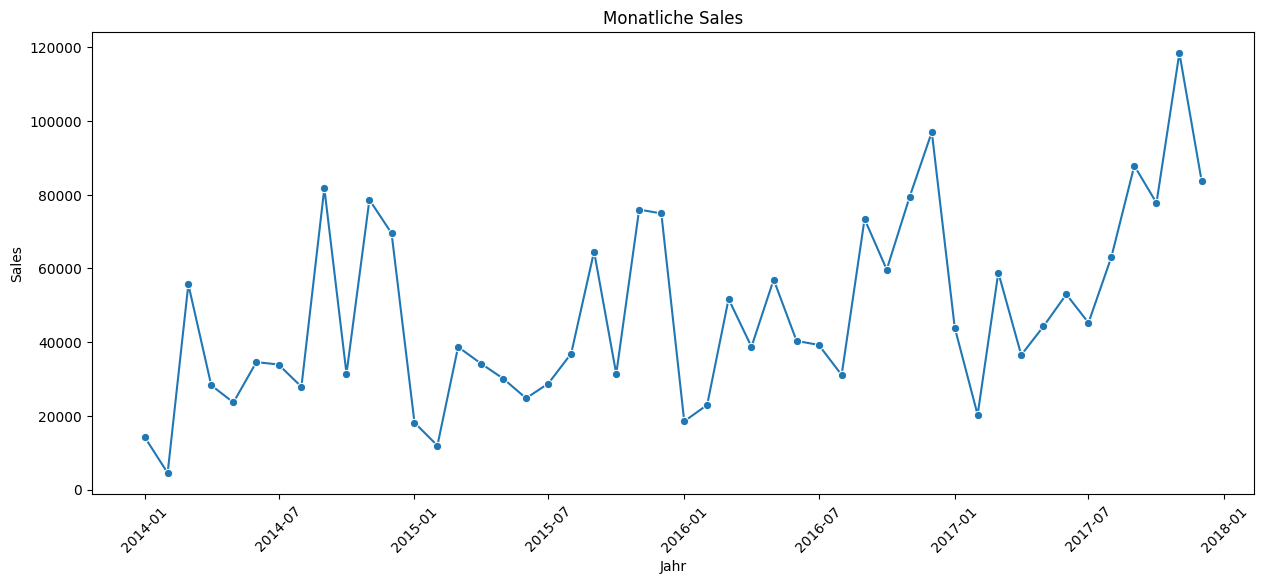

In [50]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=monthly,
    x="Year-Month",
    y="Sales",
    marker="o"
)

plt.title("Monatliche Sales")
plt.xlabel("Jahr")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [51]:
monthly_avg = (
    df.groupby("Order Month")["Sales"]
      .mean()
)

monthly_avg

Order Month
1     249.146550
2     199.170838
3     294.548116
4     206.230731
5     210.923553
6     212.996763
7     207.377601
8     225.274877
9     222.451154
10    244.594609
11    239.606438
12    231.032318
Name: Sales, dtype: float64

In [52]:
sales_month_year = (
    df.groupby(["Order Year", "Order Month"])["Sales"]
      .sum()
      .reset_index()
)

sales_month_year.head(15)

,Order Year,Order Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


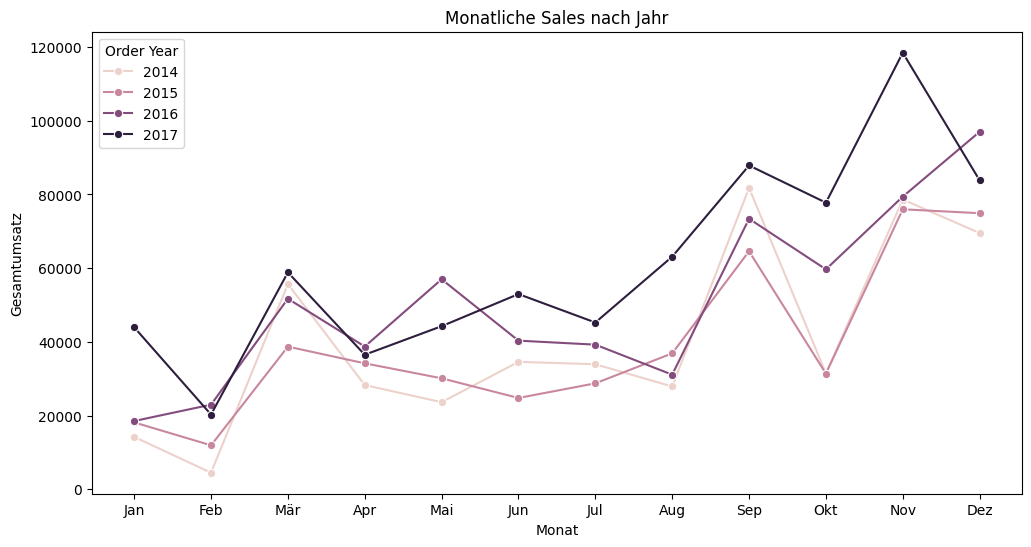

In [53]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=sales_month_year,
    x="Order Month",
    y="Sales",
    hue="Order Year",
    marker="o"
)

plt.title("Monatliche Sales nach Jahr")
plt.xlabel("Monat")
plt.ylabel("Gesamtumsatz")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
     "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
)

plt.show()

In [54]:
seasonality = (
    sales_month_year
    .groupby("Order Month")["Sales"]
    .agg(["mean", "std"])
)

seasonality

,mean,std
Order Month,,
1,23731.208900,13633.424657
2,14937.812850,8384.004488
3,51251.372200,8848.429599
4,34440.532150,4499.108635
5,38757.202925,14892.099850
6,38179.669825,11771.780866
7,36809.524250,7080.638212
8,39761.015750,16011.296813
9,76912.486425,10126.298161


In [55]:
seasonality.sort_values("mean")

,mean,std
Order Month,,
2,14937.812850,8384.004488
1,23731.208900,13633.424657
4,34440.532150,4499.108635
7,36809.524250,7080.638212
6,38179.669825,11771.780866
5,38757.202925,14892.099850
8,39761.015750,16011.296813
10,50080.746175,22767.940085
3,51251.372200,8848.429599


In [56]:
y=df["Profit"]

In [57]:
df["Is Loss"] = (df["Profit"] < 0).astype(int)

In [58]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode",
    "Order Month",
    "Shipping Days"
]

In [59]:
df[["Profit", "Is Loss"]].head(10)

,Profit,Is Loss
0,41.9136,0
1,219.5820,0
2,6.8714,0
3,-383.0310,1
4,2.5164,0
5,14.1694,0
6,1.9656,0
7,90.7152,0
8,5.7825,0
9,34.4700,0


In [60]:
df["Is Loss"].value_counts()

Is Loss
0    8123
1    1871
Name: count, dtype: int64

In [61]:
y=df["Is Loss"]
X = df[features]

In [62]:
X.head()

,Sales,Quantity,Discount,Category,Sub-Category,Segment,Region,Ship Mode,Order Month,Shipping Days
0,261.9600,2,0.00,Furniture,Bookcases,Consumer,South,Second Class,11,3
1,731.9400,3,0.00,Furniture,Chairs,Consumer,South,Second Class,11,3
2,14.6200,2,0.00,Office Supplies,Labels,Corporate,West,Second Class,6,4
3,957.5775,5,0.45,Furniture,Tables,Consumer,South,Standard Class,10,7
4,22.3680,2,0.20,Office Supplies,Storage,Consumer,South,Standard Class,10,7


In [63]:
X.shape

(9994, 10)

In [64]:
y.shape

(9994,)

In [65]:
numeric_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Order Month",
    "Shipping Days"
]

categorical_features = [
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode"
]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)

In [67]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)

print("\nTraining Klassen:")
print(y_train.value_counts(normalize=True))

print("\nTest Klassen:")
print(y_test.value_counts(normalize=True))

Training: (7995, 10)
Test: (1999, 10)

Training Klassen:
Is Loss
0    0.812758
1    0.187242
Name: proportion, dtype: float64

Test Klassen:
Is Loss
0    0.812906
1    0.187094
Name: proportion, dtype: float64


In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [70]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [71]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(7995, 36)
(1999, 36)


In [72]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['cat__Category_Furniture', 'cat__Category_Office Supplies',
       'cat__Category_Technology', 'cat__Sub-Category_Accessories',
       'cat__Sub-Category_Appliances', 'cat__Sub-Category_Art',
       'cat__Sub-Category_Binders', 'cat__Sub-Category_Bookcases',
       'cat__Sub-Category_Chairs', 'cat__Sub-Category_Copiers',
       'cat__Sub-Category_Envelopes', 'cat__Sub-Category_Fasteners',
       'cat__Sub-Category_Furnishings', 'cat__Sub-Category_Labels',
       'cat__Sub-Category_Machines', 'cat__Sub-Category_Paper',
       'cat__Sub-Category_Phones', 'cat__Sub-Category_Storage',
       'cat__Sub-Category_Supplies', 'cat__Sub-Category_Tables',
       'cat__Segment_Consumer', 'cat__Segment_Corporate',
       'cat__Segment_Home Office', 'cat__Region_Central',
       'cat__Region_East', 'cat__Region_South', 'cat__Region_West',
       'cat__Ship Mode_First Class', 'cat__Ship Mode_Same Day',
       'cat__Ship Mode_Second Class', 'cat__Ship Mode_Standard Class',
       'num__Sales', 

In [73]:
X_train_encoded_df = pd.DataFrame(
    X_train_encoded.toarray(),
    columns=feature_names,
    index=X_train.index
)

X_train_encoded_df.head()

,cat__Category_Furniture,cat__Category_Office Supplies,cat__Category_Technology,cat__Sub-Category_Accessories,cat__Sub-Category_Appliances,cat__Sub-Category_Art,cat__Sub-Category_Binders,cat__Sub-Category_Bookcases,cat__Sub-Category_Chairs,cat__Sub-Category_Copiers,...,cat__Region_West,cat__Ship Mode_First Class,cat__Ship Mode_Same Day,cat__Ship Mode_Second Class,cat__Ship Mode_Standard Class,num__Sales,num__Quantity,num__Discount,num__Order Month,num__Shipping Days
459,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,-0.200979,0.089514,-0.755676,1.271941,1.740414
7026,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,-0.292958,0.089514,0.214766,-1.763722,1.169792
8052,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,-0.338087,-0.358899,-0.755676,-0.245891,-0.542073
2685,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,-0.213685,-0.358899,0.214766,0.361242,0.599171
3706,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,-0.328691,-0.358899,0.214766,-1.460156,0.028549


In [74]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(X_train_encoded, y_train)

dummy_accuracy = dummy.score(
    X_test_encoded,
    y_test
)

dummy_accuracy

0.8129064532266133

In [75]:
from sklearn.metrics import classification_report

y_dummy_pred = dummy.predict(X_test_encoded)

print(
    classification_report(
        y_test,
        y_dummy_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1625
           1       0.00      0.00      0.00       374

    accuracy                           0.81      1999
   macro avg       0.41      0.50      0.45      1999
weighted avg       0.66      0.81      0.73      1999



In [76]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [77]:
logreg_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Segment', 'Region',
                                                   'Ship Mode']),
                                                 ('num', StandardScaler(),
                                                  ['Sales', 'Quantity',
                                                   'Discount', 'Order Month',
                                                   'Shipping Days'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [78]:
y_pred = logreg_pipeline.predict(X_test)

In [79]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1625
           1       0.72      0.96      0.82       374

    accuracy                           0.92      1999
   macro avg       0.85      0.94      0.88      1999
weighted avg       0.94      0.92      0.93      1999



In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

In [81]:
cm

array([[1482,  143],
       [  15,  359]])

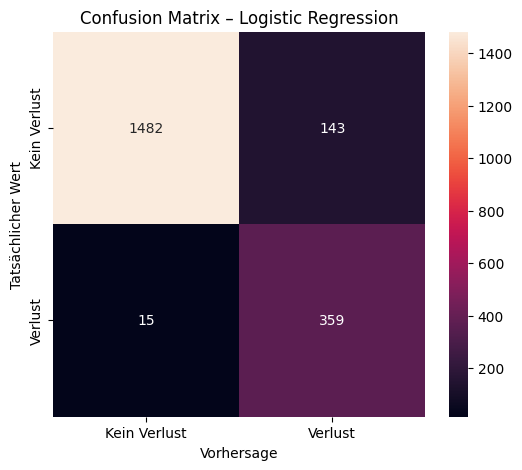

In [82]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Kein Verlust", "Verlust"],
    yticklabels=["Kein Verlust", "Verlust"]
)

plt.xlabel("Vorhersage")
plt.ylabel("Tatsächlicher Wert")
plt.title("Confusion Matrix – Logistic Regression")

plt.show()

2.Modell: Random Forest

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators = 200,
        random_state = 42,
        class_weight = "balanced",
        n_jobs = -1
    ))
])

In [84]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Segment', 'Region',
                                                   'Ship Mode']),
                                                 ('num', StandardScaler(),
                                                  ['Sales', 'Quantity',
                                                   'Discount', 'Order Month',
                                                   'Shipping Days'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [85]:
y_pred_rf = rf_pipeline.predict(X_test)

In [86]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1625
           1       0.90      0.80      0.85       374

    accuracy                           0.95      1999
   macro avg       0.93      0.89      0.91      1999
weighted avg       0.94      0.95      0.94      1999



LOGISTIC REGRESSION

"Lieber einmal zu viel warnen,
 als einen Verlust zu übersehen."

Recall     96 %
Precision  72 %


RANDOM FOREST

"Ich warne seltener,
 aber wenn ich warne, liege ich häufiger richtig."

Recall     80 %
Precision  90 %

In [87]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_rf

array([[1591,   34],
       [  74,  300]])

In [88]:
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [89]:
importances = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

In [90]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [91]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
33,num__Discount,0.482695
31,num__Sales,0.091335
34,num__Order Month,0.039215
15,cat__Sub-Category_Paper,0.038401
32,num__Quantity,0.035505
6,cat__Sub-Category_Binders,0.033076
35,num__Shipping Days,0.026157
17,cat__Sub-Category_Storage,0.025902
0,cat__Category_Furniture,0.022568
23,cat__Region_Central,0.022174


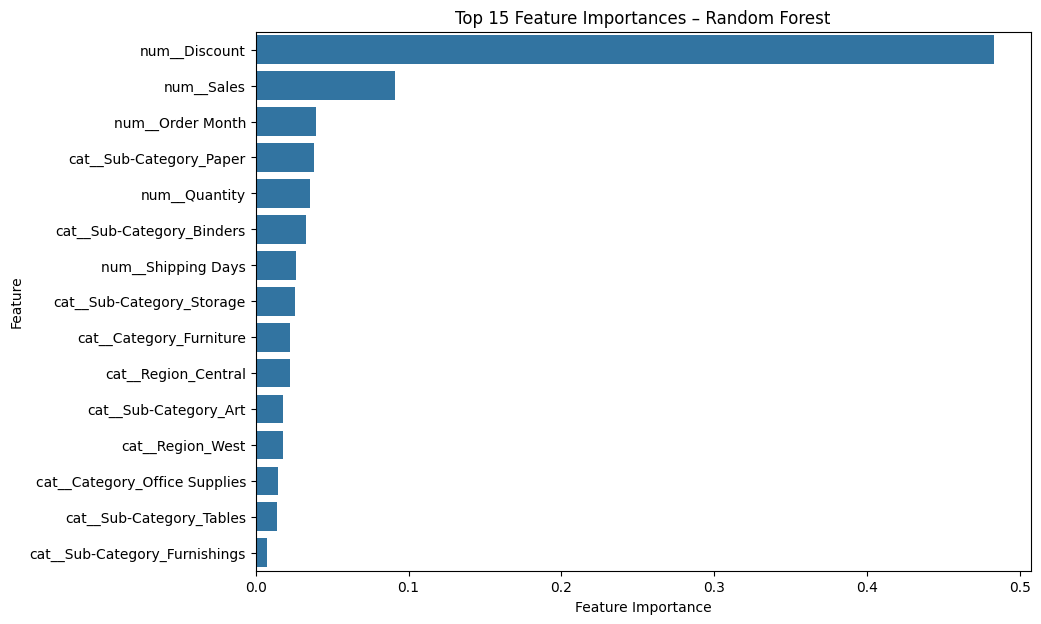

In [92]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances – Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [93]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats = 10,
    random_state =42,
    scoring="f1"
)

In [94]:
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    "Importance",
    ascending = False
)

perm_df

,Feature,Importance,Std
2,Discount,0.614802,0.016874
4,Sub-Category,0.060333,0.008713
0,Sales,0.017495,0.004907
1,Quantity,0.015636,0.006605
9,Shipping Days,0.006937,0.003877
8,Order Month,0.006480,0.005235
5,Segment,0.005331,0.005573
3,Category,0.003809,0.005253
6,Region,-0.000534,0.008141
7,Ship Mode,-0.005209,0.004542


Features reduzieren....

In [95]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode",
    "Order Month",
    "Shipping Days"
]

features_reduced = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Segment",
    "Order Month",
    "Shipping Days"
]

In [96]:
X_reduced =  df[features_reduced]

In [97]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
categorical_features_reduced = [
    "Category",
    "Sub-Category",
    "Segment"
]

In [99]:
numeric_features_reduced = [
    "Sales",
    "Quantity",
    "Discount",
    "Order Month",
    "Shipping Days"
]

In [100]:
preprocessor_reduced = ColumnTransformer([
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features_reduced
    ),
    (
        "num",
        StandardScaler(),
        numeric_features_reduced
    )
])

In [101]:
rf_reduced = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_reduced.fit(X_train_red, y_train_red)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Sub-Category',
                                                   'Segment']),
                                                 ('num', StandardScaler(),
                                                  ['Sales', 'Quantity',
                                                   'Discount', 'Order Month',
                                                   'Shipping Days'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [102]:
y_pred_red = rf_reduced.predict(X_test_red)

print(classification_report(
    y_test_red,
    y_pred_red
))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1625
           1       0.88      0.84      0.86       374

    accuracy                           0.95      1999
   macro avg       0.92      0.91      0.91      1999
weighted avg       0.95      0.95      0.95      1999



In [103]:
confusion_matrix(
    y_test_red,
    y_pred_red
)

array([[1583,   42],
       [  60,  314]])

In [104]:
cm_red = confusion_matrix(
    y_test_red,
    y_pred_red
)

cm_red

array([[1583,   42],
       [  60,  314]])

##### 5-cross validation

In [105]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_reduced,
    X_train_red,
    y_train_red,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print(cv_scores)
print("Durchschnitt:", cv_scores.mean())
print("Standardabweichung:", cv_scores.std())

[0.86772487 0.83729433 0.83508772 0.84391081 0.82746479]
Durchschnitt: 0.8422965029308827
Standardabweichung: 0.013756276570109784


In [106]:
cv_scores_full = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print(cv_scores_full)
print("Durchschnitt:", cv_scores_full.mean())
print("Standardabweichung:", cv_scores_full.std())

[0.83544304 0.83241252 0.83243243 0.8441331  0.82733813]
Durchschnitt: 0.834351844549729
Standardabweichung: 0.0055407755335884126
